In [8]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import kagglehub
from sklearn.utils import resample
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [9]:
print("--- 1. Downloading and Locating Dataset ---")
# Download dataset using kagglehub
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Downloaded Path to dataset files:", path)

base_dir = None
for root, dirs, files in os.walk(path):
    # Dynamically find the exact directory containing the train/test splits
    if 'train' in dirs and 'test' in dirs:
        if os.path.exists(os.path.join(root, 'train', 'NORMAL')):
            base_dir = root
            break

if base_dir is None:
    raise ValueError("Dataset 'train' and 'test' folders not found in the downloaded path.")
    
print(f"Dataset active directory located at: {base_dir}")

--- 1. Downloading and Locating Dataset ---
Downloaded Path to dataset files: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia
Dataset active directory located at: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray


In [10]:
print("\n--- 2. Data Preprocessing & Class Balancing ---")
data = []

for split in ['train', 'test']:  
    for cls in ['NORMAL', 'PNEUMONIA']:
        folder = os.path.join(base_dir, split, cls)
        if os.path.exists(folder):
            for file in os.listdir(folder):
                if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    data.append({'Split': split, 'Class': cls, 'Path': os.path.join(folder, file)})

df = pd.DataFrame(data)

if df.empty:
    raise ValueError("DataFrame is empty. No images were found.")

train_df = df[df['Split'] == 'train'].copy()
val_df = df[df['Split'] == 'test'].copy()

# Oversample the minority class (NORMAL) to match PNEUMONIA
majority_class = train_df[train_df['Class'] == 'PNEUMONIA']
minority_class = train_df[train_df['Class'] == 'NORMAL']

minority_upsampled = resample(
    minority_class, 
    replace=True, 
    n_samples=len(majority_class), 
    random_state=42
)

train_df_balanced = pd.concat([majority_class, minority_upsampled]).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Training data balanced: \n{train_df_balanced['Class'].value_counts()}\n")


--- 2. Data Preprocessing & Class Balancing ---
Training data balanced: 
Class
PNEUMONIA    3875
NORMAL       3875
Name: count, dtype: int64



In [11]:
print("--- 3. Setting up Data Generators ---")
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df_balanced,
    x_col='Path', y_col='Class',
    target_size=(224, 224),
    batch_size=32, class_mode='binary'
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='Path', y_col='Class',
    target_size=(224, 224),
    batch_size=32, class_mode='binary',
    shuffle=False
)

--- 3. Setting up Data Generators ---
Found 7750 validated image filenames belonging to 2 classes.
Found 624 validated image filenames belonging to 2 classes.


In [13]:
print("\n--- 4. Building EfficientNetB0 Model ---")
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False 

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x) 
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


--- 4. Building EfficientNetB0 Model ---
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [14]:
class TimeHistory(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs={}):
        self.total_time_start = time.time()
    def on_epoch_begin(self, epoch, logs={}):
        self.epoch_time_start = time.time()
    def on_epoch_end(self, epoch, logs={}):
        print(f" -> Epoch {epoch + 1} Time: {time.time() - self.epoch_time_start:.2f} seconds")
    def on_train_end(self, logs={}):
        total_time = time.time() - self.total_time_start
        print(f"\nTotal Training Time: {total_time:.2f} seconds ({total_time/60:.2f} minutes)")

early_stop = callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True, 
    verbose=1
)

print("\n--- 5. Starting Training ---")
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30, 
    callbacks=[TimeHistory(), early_stop],
    verbose=1
)

# Save Model
model_path = '/kaggle/working/efficientnet_balanced.keras'
model.save(model_path)
size_mb = os.path.getsize(model_path) / (1024 * 1024)
print(f"\nModel Saved. Physical Size on Disk: {size_mb:.2f} MB")


--- 5. Starting Training ---


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30


I0000 00:00:1773405569.897128     167 service.cc:152] XLA service 0x7e8d980042b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773405569.897159     167 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773405569.897163     167 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1773405572.062398     167 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-13 12:39:38.553343: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-13 12:39:38.696717: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-13 12:39:39.032994: E external/local_xl

 63/243 ━━━━━━━━━━━━━━━━━━━━ 2:39 883ms/step - accuracy: 0.7211 - loss: 0.5421

2026-03-13 12:40:46.809364: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-13 12:40:46.944018: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-13 12:40:47.250728: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-13 12:40:47.390433: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-13 12:40:48.069481: E external/local_xla/xla/stream_

243/243 ━━━━━━━━━━━━━━━━━━━━ 0s 864ms/step - accuracy: 0.8227 - loss: 0.3993

2026-03-13 12:43:34.504444: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-13 12:43:34.643649: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-13 12:43:34.957300: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-13 12:43:35.098074: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-13 12:43:35.778519: E external/local_xla/xla/stream_

 -> Epoch 1 Time: 258.86 seconds
243/243 ━━━━━━━━━━━━━━━━━━━━ 259s 963ms/step - accuracy: 0.8229 - loss: 0.3989 - val_accuracy: 0.8397 - val_loss: 0.3351
Epoch 2/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 0s 616ms/step - accuracy: 0.9161 - loss: 0.2122 -> Epoch 2 Time: 154.43 seconds
243/243 ━━━━━━━━━━━━━━━━━━━━ 155s 636ms/step - accuracy: 0.9161 - loss: 0.2121 - val_accuracy: 0.8558 - val_loss: 0.3067
Epoch 3/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 0s 616ms/step - accuracy: 0.9314 - loss: 0.1785 -> Epoch 3 Time: 154.30 seconds
243/243 ━━━━━━━━━━━━━━━━━━━━ 154s 635ms/step - accuracy: 0.9314 - loss: 0.1785 - val_accuracy: 0.8750 - val_loss: 0.2889
Epoch 4/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 0s 610ms/step - accuracy: 0.9391 - loss: 0.1653 -> Epoch 4 Time: 152.77 seconds
243/243 ━━━━━━━━━━━━━━━━━━━━ 153s 629ms/step - accuracy: 0.9391 - loss: 0.1653 - val_accuracy: 0.8686 - val_loss: 0.2766
Epoch 5/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 0s 611ms/step - accuracy: 0.9417 - loss: 0.1539 -> Epoch 5 Time: 153.12 seconds
243


--- 4. Generating Plots ---


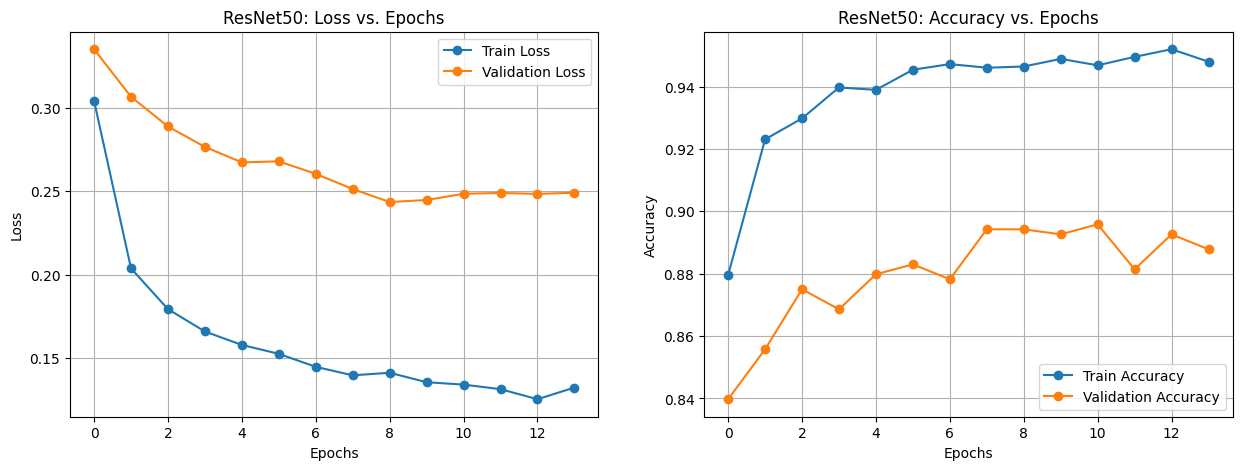

In [15]:
print("\n--- 4. Generating Plots ---")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss', marker='o')
axes[0].plot(history.history['val_loss'], label='Validation Loss', marker='o')
axes[0].set_title('ResNet50: Loss vs. Epochs')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train Accuracy', marker='o')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
axes[1].set_title('ResNet50: Accuracy vs. Epochs')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.show()


--- 5. Detailed Evaluation ---
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 221ms/step
Accuracy:  0.8942
Precision: 0.8971
Recall:    0.9385
F1 Score:  0.9173


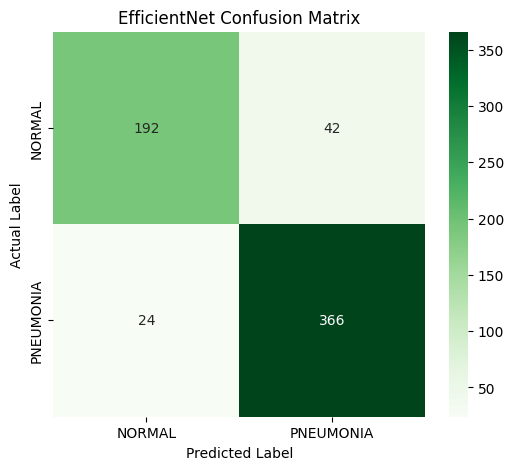

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt  # <--- FIXED TYPO HERE
import seaborn as sns
import numpy as np

print("\n--- 5. Detailed Evaluation ---")
# Get actual labels directly from the generator
y_true = val_generator.classes 

# Get raw predictions and convert to binary classes (0 or 1)
y_pred_probs = model.predict(val_generator)
y_pred = (y_pred_probs > 0.5).astype(int)

# Calculate Metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")

# Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))

# Extract the exact class names the generator used
class_labels = list(val_generator.class_indices.keys())

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=class_labels, 
            yticklabels=class_labels)

plt.title('EfficientNet Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()